#### SARIMA

SARIMA stands for Seasonal Auto Regression Integrated Moving Average.

It can work with the seasonal data with repeating cycles (data that repeats after a fixed interval of time.)

SARIMA can easily handle the seasonal data with repeating cycles.

    (a.)    weekly repetation

    (b.)    monthly repetation

    (c.)    yearly repetation



ARIMA can learn 

    (a.)    past values

    (b.)    trends

    (c.)    autocorrelation 

    (d.)    seasonality

But it cannot capture properly the seasonal data with the repeatig cycles


#### Difference between ARIMA and SARIMA

| ARIMA                    | SARIMA                        |
| ------------------------ | ----------------------------- |
|  Handles Trend           |  Handles trend + seasonality  |
|  no seasonal memory      |   seasonal memory             |
|  Poor on repeating cycles|  Excellent on repeating cycles|
|  Simple                  |    Powerful                   |


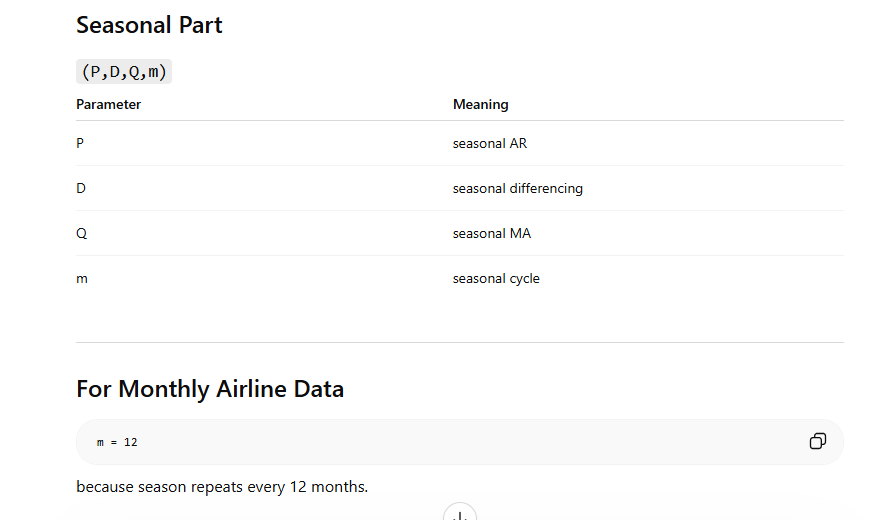

#### Step 1: Import all the necessary libraries

In [572]:
import      numpy                   as      np
import      pandas                  as      pd
import      matplotlib.pyplot       as      plt
import      seaborn                 as      sns

from        statsmodels.tsa.statespace.sarimax  import SARIMAX


import      warnings
warnings.filterwarnings("ignore")

#### OBSERVATIONS:

1.  SARIMA ==================>  It can handle the seasonal data with the repeating cyclic patterns.

#### Step 2: Load the dataset

In [573]:
#### Load the dataset

df = pd.read_csv('AirPassengers.csv')

In [574]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data for the starting date of each month beginning from 1949 till 1960.

#### Step 3: Perform Data Exploration

In [575]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [576]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [577]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 144


In [578]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (144, 2)


In [579]:
#### get the column used in the dataset

df.columns

Index(['date', 'value'], dtype='object')

In [580]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### Step 4: Perform Data Cleaning and Feature Engineering

In [581]:
#### Convert the object type of date column to date

df['date']  =   pd.to_datetime(df['date'])

In [582]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The date column has been converted from 'object' type to 'datetime' type.

In [583]:
#### To set the date column as an index

df.set_index('date',inplace=True)

In [584]:
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


#### OBSERVATIONS:

1.  The date column has been set as an index.

In [585]:
#### To check for the NULL records in the dataframe

df.isnull().sum()

value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [586]:
#### Rename the column name 'value' to 'Passengers'

df.rename(columns={'value':'Passengers'},inplace=True)

#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passenegers'.

#### Step 5: Plot the time series data

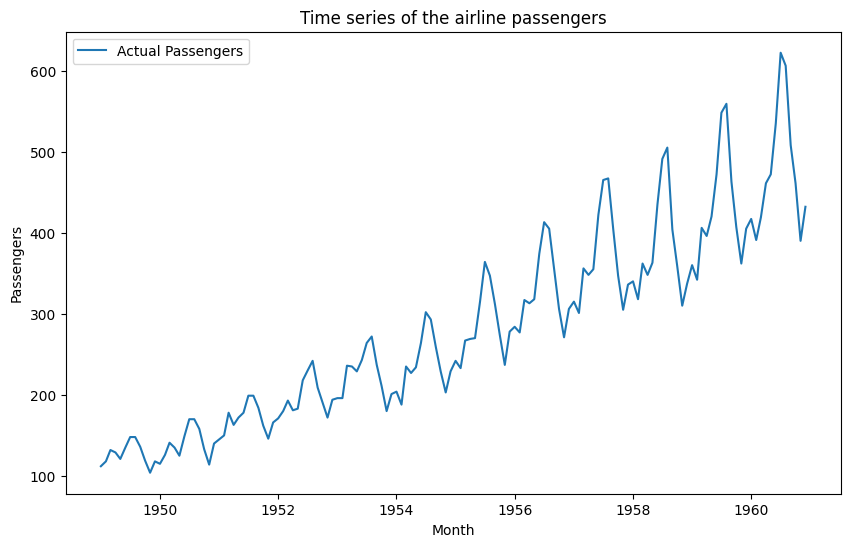

In [587]:
plt.figure(figsize=(10,6))

#### plot the original time series
plt.plot(df.index, df['Passengers'], label = 'Actual Passengers')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the passengers data for the starting date of every month starting from 1944 till 1960.

2.  With the increase in years, the number of passengers also increases, so the trned also increases.

3.  As the trend continuously increases in the upward direction, so the time series is non stationary in nature.

#### Step 6: Divide the dataset into training and testing data

In [588]:
#### Divide the dataset into training and testing

train = df.iloc[:120]

In [589]:
train

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1958-08-01,505
1958-09-01,404
1958-10-01,359


#### OBSERVATIONS:

1.  The training data has all the old records of Passengers ranging between 1949 till 1958.

In [590]:
test = df.iloc[120:]

In [591]:
test

,Passengers
date,
1959-01-01,360
1959-02-01,342
1959-03-01,406
1959-04-01,396
1959-05-01,420
1959-06-01,472
1959-07-01,548
1959-08-01,559
1959-09-01,463


#### OBSERVATIONS:

1.  The testing data contains the latest records ranging from 1959 till 1960.

#### OBSERVATIONS:

1.  The main aim of dividing the dataset into training and testing data is that

    (a.)    We train our model on the old data

    (b.)    We perform testing on the new or unseen data or any new test data.

#### Step 7: Build the SARIMA model

In [592]:
from    statsmodels.tsa.statespace.sarimax  import  SARIMAX


#### Create an object for SARIMAX

sarimax = SARIMAX(
    train['Passengers']                                     ,
    order                   =       (1,1,1)                 ,
    seasonal_order          =   (1,1,1,12)
)

#### OBSERVATIONS:

1.  The object for SARIMA has been created with the following parameters :-------------

    (a.)    Input training data train['Passengers'] ===========> Model training is always done on the training data

    (b.)    order(1,1,1)                            ===========>  ARIMA model

    (c.)    seasonal_order(1,1,1,12)                ===========>  SARIMA model as it can easily capture patterns and insights from the seasonal data with the repeating cycles.

            (i) P = 1 ===========>  Current value depends on one previous value

            (ii) D = 1 ===========>  First order of differencing is needed

            (iii) Q = 1 ===========> uses previous error term to forecast future value

            (iv)  m = 12 ===========> data repeating adter every 12 months (seasonal cycle path)

#### Step 8: Train the SARIMA Model

In [593]:
#### Train the model

model_fit = sarimax.fit()

In [594]:
model_fit

#### OBSERVATIONS:

1.  The SARIMA model is trained.

2.  During the model training, SARIMA learns:----

    (a.)    trends patterns

    (b.)    seasonality patterns

    (c.)    lag relationships

    (d.)    forecast the errors

#### Step 9: Give the summary of the model

In [595]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -398.830
Date:                            Thu, 28 May 2026   AIC                            807.660
Time:                                    19:03:46   BIC                            821.024
Sample:                                01-01-1949   HQIC                           813.078
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4901      0.351     -1.397      0.162      -1.178       0.197
ma.L1          0.2579      0.373      0.691      0.490      -0.474       0.990
ar.S.L12      -0.9165      0.413     -2.219      0.026      -1.726      -0.107
ma.S.L12       0.8622      0.496      1.737      0.082      -0.111       1.835
sigma2       100.3821     13.369      7.509      0.000      74.179     126.585
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.81
Prob(Q):                              0.96   Prob(JB):                         0.40
Heteroskedasticity (H):               1.58   Skew:                            -0.04
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### OBSERVATIONS:

1.  The summary of the SARIMA model provides the information regarding :-------------

    (a.)    AIC Score

    (b.)    BIC Score

    (c.)    p values   etc

2.  Lower the AIC Score ===================> better is the model.

#### Step 10: Forecast future values

In [596]:
#### create the forecast object

forecast_obj = model_fit.get_forecast(steps=len(test))

In [597]:
forecast_obj

#### OBSERVATIONS:

1.  With the help of the training object where we have trained our model with old data, we have forecasted the data equal to the length of the test data.

#### Step 11: Extract the forecasted values

In [598]:
forecasted_values = forecast_obj.predicted_mean

In [599]:
forecasted_values

1959-01-01    342.279140
1959-02-01    320.435764
1959-03-01    366.255215
1959-04-01    353.324478
1959-05-01    367.592209
1959-06-01    437.482349
1959-07-01    493.549301
1959-08-01    506.824182
1959-09-01    408.200236
1959-10-01    362.348295
1959-11-01    312.631242
1959-12-01    339.852248
1960-01-01    344.038727
1960-02-01    322.012769
1960-03-01    366.183858
1960-04-01    352.263781
1960-05-01    367.207221
1960-06-01    439.028759
1960-07-01    495.035455
1960-08-01    508.974354
1960-09-01    408.173060
1960-10-01    363.101779
1960-11-01    314.041957
1960-12-01    341.060383
Freq: MS, Name: predicted_mean, dtype: float64

#### OBSERVATIONS:

1.  We have used the predicted mean function to forcase the airline passengers data for the last 24 months.

#### Step 12: Get the confidence interval

In [600]:
#### Get the confidence interval

confidence_interval = forecast_obj.conf_int()

In [601]:
confidence_interval

,lower Passengers,upper Passengers
1959-01-01,322.626496,361.931784
1959-02-01,295.661163,345.210366
1959-03-01,336.025699,396.484731
1959-04-01,319.015766,387.633191
1959-05-01,329.407424,405.776995
1959-06-01,395.885378,479.079320
1959-07-01,448.751825,538.346776
1959-08-01,459.062054,554.586310
1959-09-01,357.636875,458.763598
1959-10-01,309.135633,415.560957


#### OBSERVATIONS:

1.  We have obtained the confidence intervals for each starting date of the month ranging from 1959 till 1960.

#### Step 13: Plot the forecasted values along with the confidence intervals

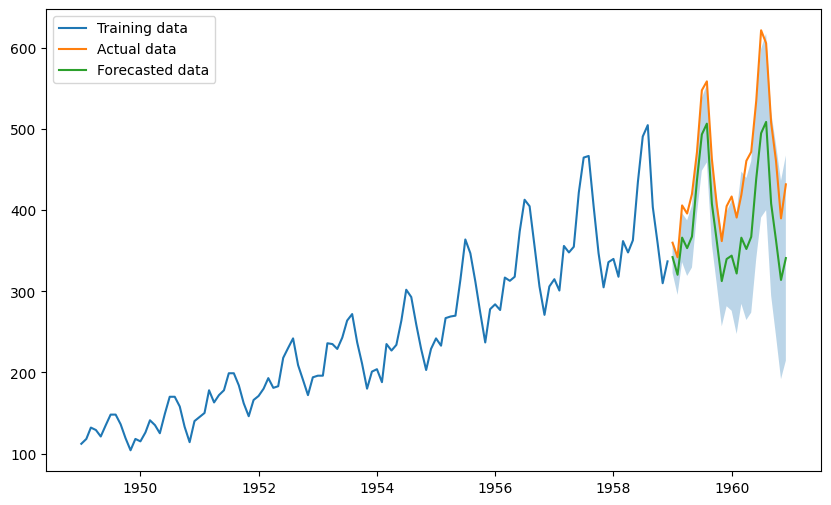

In [602]:
plt.figure(figsize=(10,6))

#### plot the original data points
plt.plot(train.index, train['Passengers'], label = 'Training data')

#### plot the actual data points
plt.plot(test.index,  test['Passengers'], label = 'Actual data')

#### plot the forecasted data points
plt.plot(test.index, forecasted_values, label = 'Forecasted data')

#### plot the confidence intervals
plt.fill_between(
    test.index                                    ,
    confidence_interval.iloc[:,0]                 ,
    confidence_interval.iloc[:,1]                 ,
    alpha = 0.3
)

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  After applying SARIMA on the above dataset, we have seen that there is an upward trend for the forecasted values.

2.  So from this, it is concluded that SARIMA has successfully captured

    (a.) trends

    (b.) lag relationships

    (c.) strong seasonality with repeating cyclic patterns in every fixed interval of time.

3.  Even in the forecasting, SARIMA model can handle seasonal patterns in the data which was not in case of ARIMA model

    (a.)    In ARIMA, there was a straight line after the forecasting and the trend was removed whereas in SARIMA, the seasonal trend still exists as it can handle the seasonal data with repeating patterns.